In [1]:
import matplotlib.pyplot as plt
plt.style.use('../styles/gcpeixoto-book.mplstyle')

(cap:acumulacoes)=
# Acumulações

<div class="chapter-thumb">
    <div class="chapter-oa">
        <h2>Objetivos de aprendizagem</h2>
        <ul>
        <li>Explicar a estrutura lógica e as propriedades matemáticas fundamentais dos operadores de somatório e produtório;</li>
	    <li>Implementar algoritmos eficientes em Python para o cálculo de acumulações de alto nível e aproximações de funções via séries finitas;</li>
	    <li>Demonstrar a necessidade técnica da "ponte" logarítmica em contextos de computação científica, analisando como a conversão de produtórios em somatórios resolve problemas de instabilidade numérica;</li>
	    <li>Resolver problemas práticos usando conceitos de acumulação;</li>
        </ul>
    </div>        
    <div class="quote-box">
        <p><em> 
        </p></em>
    </div>        
</div>

## Operadores de acumulação: somatórios e produtórios

Os operadores de acumulação são os "motores" da matemática discreta, consolidando informações de uma sequência em um único valor. O _somatório_ ($\sum$) atua como a versão discretizada da integral – que lida com o acúmulo contínuo ($\int$) –, somando fatias de dados passo a passo. Já o _produtório_ ($\prod$) é o operador fundamental associado à multiplicação. Na prática, o somatório nos dá a visão linear e aditiva de um sistema, enquanto o produtório nos revela o comportamento multiplicativo e, muitas vezes, exponencial ou probabilístico de um processo.

Somatórios e produtórios possuem a mesma estrutura lógica, que se traduz diretamente para loops em Python:

1.  _Índice de início_ (ex: $i=0$).
2.  _Limite superior_ (ex: $n$).
3.  _Lei de formação_ (termo $a_i$).

Por exemplo:

- $\displaystyle\sum_{i=0}^n i^2 = 1^2 + 2^2 + \ldots + n^2$
- $\displaystyle\prod_{i=1}^n i^2 = 1^2 \times 2^2 \times \ldots \times n^2$

No computador, ambos os operadores são implementados de maneira idêntica, exceto pela operação fundamental:

In [17]:
# somatório
soma = 0  # elemento neutro da soma
n = 5
for i in range(1, n+1):
    soma += i**2

# produtório
produto = 1  # elemento neutro da multiplicação
for i in range(1, n+1):
    produto *= i**2
    
print(f"Soma = {soma}")
print(f"Produto = {produto}")

Soma = 55
Produto = 14400


```{admonition}Sobrecarga de operadores

Python permite a _sobrecarga de operadores_, o que significa que o mesmo símbolo (`+=`) pode ter comportamentos diferentes. Por exemplo:

- Em **inteiros**, ele soma valores.
- Em **listas**, ele realiza uma operação de extensão (append de múltiplos elementos).

O uso de `+=` em listas é geralmente mais eficiente do que `lista = lista + [item]`, pois o Python tenta realizar a operação _inplace_ (no mesmo local da memória), evitando criar cópias desnecessárias da lista inteira.
```

### Acumulação de alto nível

Com as funções `sum()` e `prod()`, podemos criar formas mais simples de acumular.

In [18]:
import math

medidas = [0.12, 0.05, -0.02, 0.10, 0.08]
soma = sum(medidas)
print(f"Erro total acumulado: {soma:.2f} mm")

probabilidades = [0.99, 0.98, 0.95, 0.99]
chance_total = math.prod(probabilidades)
print(f"Probabilidade de Sucesso do Sistema: {chance_total * 100:.2f}%")

Erro total acumulado: 0.33 mm
Probabilidade de Sucesso do Sistema: 91.25%



### Séries 

Uma _série_ surge quando somamos os termos de uma sequência. A diferença fundamental entre uma sequência e uma série é que a sequência é uma lista de números, enquanto a série é a soma desses números. Uma _série finita_ é a soma de um número determinado de termos ($n$). Ela sempre resulta em um valor real definido, desde que cada termo da sequência também seja real. Em uma _série infinita_ o desafio aumenta. Somamos termos de uma sequência que nunca termina ($n \to \infty$). O resultado pode ser um número finito (convergência) ou o infinito/indeterminação (divergência).

Abaixo, damos exemplos de séries finitas e infinitas clássicas:

- Séries convergentes (estáveis)
    - geométrica ($|q| < 1$): $\sum_{n=0}^{\infty} aq^n = \frac{a}{1-q}$

    - Basel (inverso dos quadrados): $\sum_{n=1}^{\infty} \frac{1}{n^2} = \frac{\pi^2}{6}$

    - $e$: $\sum_{n=0}^{\infty} \frac{1}{n!} = e$

- Séries divergentes (instáveis)

    - harmônica: $\sum_{n=1}^{\infty} \frac{1}{n} = 1 + \frac{1}{2} + \frac{1}{3} + \dots = \infty$
    
    - aritmética: $\sum_{n=1}^{n} i = \frac{n(n+1)}{2}$ (sempre diverge se $n \to \infty$)
    
    - Grandi: $\sum_{n=0}^{\infty} (-1)^n = 1 - 1 + 1 - 1 + \dots$ (diverge por oscilação)

In [16]:
import math

def calc_serie(nome, lei, n_termos):
    """Calcula a soma parcial de uma série baseada em uma lei de formação."""
    
    soma_acumulada = 0   
    print(f"--- Calculando: {nome}")
    
    for n in range(n_termos):
        try:
            termo_atual = lei(n)
            soma_acumulada += termo_atual
        except ZeroDivisionError:
            continue
            
    return soma_acumulada

# Leis
lei_geo = lambda n: (0.5)**n
lei_basel = lambda n: 1 / (n+1)**2
lei_harmonica = lambda n: 1 / (n+1)
lei_euler = lambda n: 1 / math.factorial(n)

# Execução
n_limite = 10

res_geo = calc_serie("Geométrica (q=0.5)", lei_geo, n_limite)
res_basel = calc_serie("Basel (1/n^2)", lei_basel, n_limite)
res_euler = calc_serie("Euler (1/n!)", lei_euler, n_limite)
res_harm = calc_serie("Harmônica (Divergente)", lei_harmonica, n_limite)

print(f"\nResultados após {n_limite} termos:")
print(f"--- Geométrica: {res_geo:.6f} (Esperado: 2.0)")
print(f"--- Basel:      {res_basel:.6f} (Esperado: {math.pi**2/6:.6f})")
print(f"--- Euler:      {res_euler:.6f} (Esperado: {math.e:.6f})")
print(f"--- Harmônica:  {res_harm:.6f} (Continua crescendo...)")

--- Calculando: Geométrica (q=0.5)
--- Calculando: Basel (1/n^2)
--- Calculando: Euler (1/n!)
--- Calculando: Harmônica (Divergente)

Resultados após 10 termos:
--- Geométrica: 1.998047 (Esperado: 2.0)
--- Basel:      1.549768 (Esperado: 1.644934)
--- Euler:      2.718282 (Esperado: 2.718282)
--- Harmônica:  2.928968 (Continua crescendo...)


#### Séries de Taylor e Maclaurin

A série de Taylor é uma expansão de uma função em uma soma infinita de termos calculados a partir das derivadas da função em um único ponto $a$. Quando esse ponto é a origem ($a=0$), chamamos a expansão de série de Maclaurin:

- Taylor: 

$$f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!}(x-a)^n$$

- Maclaurin:

$$f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(0)}{n!}x^n$$

Séries de Maclaurin comuns são:

- $e^x = 1 + x + \frac{x^2}{2!} + \dots$
- $\sin(x) = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \dots$
- $\cos(x) = 1 - \frac{x^2}{2!} + \frac{x^4}{4!} - \dots$

Podemos gerar a série de Taylor usando o `sympy`:

In [75]:
import sympy as sp

def gerar_taylor(funcao_str, ponto_a, n_termos):
    x = sp.Symbol('x')
    f = sp.sympify(funcao_str)
    
    # Gera a série de Taylor e remove o termo O(x^n)
    serie = f.series(x, ponto_a, n_termos).removeO()
    
    print(f"Função: {f}")
    print(f"Expansão em torno de a = {ponto_a} com {n_termos} termos:")
    return x, serie

# Exemplo: Maclaurin de exp(x)
x, exp_maclaurin = gerar_taylor("exp(x)", 0, 5)
print(exp_maclaurin.subs(x, 1).evalf())  #  Aproximação de e^1 usando os primeiros 5 termos
exp_maclaurin

Função: exp(x)
Expansão em torno de a = 0 com 5 termos:
2.70833333333333


x**4/24 + x**3/6 + x**2/2 + x + 1

In [76]:
# Exemplo: Taylor de sin(x) em torno de pi/2
x, sin_taylor = gerar_taylor("sin(x)", sp.pi/2, 4)
print(sin_taylor.subs(x, 1).evalf())  #  Aproximação de sin(1) usando os primeiros 4 termos

sin_taylor

Função: sin(x)
Expansão em torno de a = pi/2 com 4 termos:
0.837095776658727


1 - (x - pi/2)**2/2

#### Série de Fourier

Diferente de Taylor, que usa polinômios, a série de Fourier decompõe funções periódicas em uma soma de senos e cossenos. É a base do processamento de sinais e da análise harmônica. Para uma função periódica com período $T = 2L$, sua fórmula é dada por:

$$f(x) \approx \frac{a_0}{2} + \sum_{n=1}^{N} [a_n \cos(\frac{n\pi x}{L}) + b_n \sin(\frac{n\pi x}{L})],$$

onde 

- $a_0 = \frac{1}{L} \int_{-L}^L f(x) \, dx$
- $a_n = \frac{1}{L} \int_{-L}^L f(x) \cos(\frac{n\pi x}{L})  \, dx$
- $b_n = \frac{1}{L} \int_{-L}^L f(x) \sin(\frac{n\pi x}{L})  \, dx$


Uma aplicação discreta de Fourier é a aproximação de ondas. No caso limite, da quadrada:

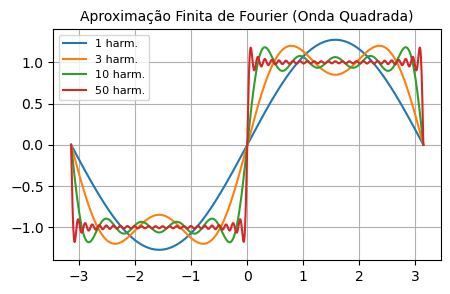

In [82]:
import numpy as np
import matplotlib.pyplot as plt

def fourier_finito(x, n_harmonicos, L):
    """Aproximação da onda quadrada via Fourier."""
    
    soma = 0
    
    # Para onda quadrada (ímpar), an = 0 e bn = 4/(n*pi) para n ímpares
    for n in range(1, n_harmonicos + 1, 2):
        bn = 4 / (n * np.pi)
        soma += bn * np.sin(n * np.pi * x / L)
    return soma

# Parâmetros
L = np.pi
x = np.linspace(-L, L, 1000)

# Visualização
_, ax = plt.subplots(figsize=(5, 3))
for n in [1, 3, 10, 50]:
    y = fourier_finito(x, n, L)
    ax.plot(x, y, label=f'{n} harm.')

ax.set_title("Aproximação Finita de Fourier (Onda Quadrada)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True)

## Propriedades matemáticas

### Somatório

Somatórios não são apenas listas de adições, mas operadores lineares que seguem regras bem definidas. Essas propriedades nos permitem simplificar algoritmos complexos e otimizar cálculos:

1. _constante_: para qualquer constante $c$,
   $$\sum_{i=1}^{n} c = nc$$

2. _escalar_: se $c$ é uma constante independente de $i$,
   $$\sum_{i=1}^{n} ca_i = c \sum_{i=1}^{n} a_i$$

3. _associatividade_:
   $$\sum_{i=1}^{n} (a_i + b_i) = \sum_{i=1}^{n} a_i + \sum_{i=1}^{n} b_i$$

4. _decomposição_:
   $$\sum_{i=1}^{n} a_i = \sum_{i=1}^{m} a_i + \sum_{i=m+1}^{n} a_i \quad (1 < m < n)$$

In [41]:
import numpy as np

def validar_sum_props(n, const, k_break=4):
    
    a = np.random.randint(1, 10, n)
    b = np.random.randint(1, 10, n)
    
    print(f"Dados: a = {a}, b = {b},  c = {const}\n")

    # constante: soma 'c' n vezes
    sum_const = sum([const for _ in range(n)])
    prop_const = n * const
    print(f"--- Prop. constante: {sum_const} == {prop_const} -> {sum_const == prop_const}")

    # escalar: somar Soma(c * a_i) vs c * Soma(a_i)
    sum_escalar = sum(const * a)
    prop_escalar = const * sum(a)
    print(f"--- Prop. Escalar: {sum_escalar} == {prop_escalar} -> {sum_escalar == prop_escalar}")

    # associatividade: Soma(a_i + b_i) vs Soma(a_i) + Soma(b_i)
    sum_linear = sum(a + b)
    prop_linear = sum(a) + sum(b)
    print(f"--- Prop. Associatividade: {sum_linear} == {prop_linear} -> {sum_linear == prop_linear}")

    # decomposição: quebrar o somatório no índice k_break
    sum_total = sum(a)
    sum_partes = sum(a[:k_break+1]) + sum(a[k_break+1:])
    print(f"--- Prop. Decomposição:  {sum_total} == {sum_partes} -> {sum_total == sum_partes}")

validar_sum_props(10, 5) 

Dados: a = [5 8 9 3 1 2 4 6 6 6], b = [1 8 6 2 5 2 9 3 2 9],  c = 5

--- Prop. constante: 50 == 50 -> True
--- Prop. Escalar: 250 == 250 -> True
--- Prop. Associatividade: 97 == 97 -> True
--- Prop. Decomposição:  50 == 50 -> True


### Produtório

Diferente do somatório, as propriedades do produtório são regidas por potências e distribuições multiplicativas:

1. _constante_ (equivale à exponenciação):
   $$\prod_{i=1}^{n} c = c^n$$

2. _escalar_:
   $$\prod_{i=1}^{n} ca_i = c^n \prod_{i=1}^{n} a_i$$

3. _associatividade_:
   $$\prod_{i=1}^{n} (a_i \cdot b_i) = \left( \prod_{i=1}^{n} a_i \right) \cdot \left( \prod_{i=1}^{n} b_i \right)$$

4. _decomposição_:
   $$\prod_{i=1}^{n} a_i = \left( \prod_{i=1}^{m} a_i \right) \cdot \left( \prod_{i=m+1}^{n} a_i \right)$$

In [47]:
import math
import numpy as np

def val_props_prod(n, const, k_break=4):
    
    a = np.random.randint(1, 10, n)
    b = np.random.randint(1, 10, n)
    
    print(f"Dados: a = {a}, b = {b}, c = {const}\n")

    # constante: 'c'ArithmeticError multiplicado n vezes
    prod_const = math.prod([const for _ in range(n)])
    prop_const = const ** n
    print(f"--- Prop. Constante: {prod_const} == {prop_const} -> {prod_const == prop_const}")

    # escalar: Prod(c * a_i) vs (c^n) * Prod(a_i)
    prod_escalar = math.prod(const * a)
    prop_escalar = (const ** n) * math.prod(a)
    print(f"--- Prop. Escalar:   {prod_escalar} == {prop_escalar} -> {math.isclose(prod_escalar, prop_escalar)}")

    # associatividade: Prod(a_i * b_i) vs Prod(a_i) * Prod(b_i)
    prod_mult = math.prod(a * b)
    prop_mult = math.prod(a) * math.prod(b)
    print(f"--- Prop. Associatividade: {prod_mult} == {prop_mult} -> {prod_mult == prop_mult}")

    # decomposição
    prod_total = math.prod(a)
    prod_partes = math.prod(a[:k_break+1]) * math.prod(a[k_break+1:])
    print(f"--- Prop. Decomposição:    {prod_total} == {prod_partes} -> {prod_total == prod_partes}")

val_props_prod(4, 2)

Dados: a = [3 4 7 9], b = [8 1 8 2], c = 2

--- Prop. Constante: 16 == 16 -> True
--- Prop. Escalar:   12096 == 12096 -> True
--- Prop. Associatividade: 96768 == 96768 -> True
--- Prop. Decomposição:    756 == 756 -> True


## A "ponte" logarítmica 

A "ponte" entre somatórios e produtórios é construída sobre uma das propriedades mais elegantes e úteis da álgebra: a propriedade logarítmica da multiplicação. Essa relação permite transitar entre o mundo multiplicativo (muitas vezes instável e explosivo) e o mundo aditivo (estável e linear).

A identidade fundamental que conecta esses dois operadores é:

$$ \log_b(\displaystyle\prod_{i=1}^n a_i) = 
\displaystyle\sum_{i=1}^n \log_b(a_i)
$$

A intuição por trás da "ponte" remete à regra básica dos logaritmos: o logaritmo de um produto é a soma dos logaritmos. Quando aplicamos isso a um produtório de $n$ termos, estamos essencialmente expandindo essa regra.A utilidade deste resultado é enorme. Vejamos apenas dois casos:

- **O problema do _underflow_**: em computação, as probabilidades são números entre 0 e 1. Se você multiplicar 1.000 probabilidades de 0,1, o resultado será $10^{−1000}$. O problema é: a maioria dos computadores (usando precisão de 64 bits) "desiste" e arredonda esse valor para zero absoluto (_underflow_). A solução, porém é: ao aplicar o logaritmo transformamos $10^{−1000}$ no número −1000. O computador consegue lidar com −1000 com extrema facilidade e precisão. 

- **Máxima verossimilhança (_likelihood_)**: para encontrar o melhor parâmetro de um modelo estatístico, precisamos maximizar a função de verossimilhança ($L$), que é um produtório: $L(\theta)= \prod P(x_i | \theta)$. Derivar um produtório para encontrar o máximo é um pesadelo matemático (exige a regra do produto repetidas vezes). Ao aplicar o logaritmo (gerando a _log-likelihood_), transformamos o produto na soma: $l(θ)= \sum \log P(x_i | \theta)$. Derivar uma soma é muito mais simples, pois a derivada da soma é a soma das derivadas. Por isso, em inteligência artificial, quase nunca calculamos a probabilidade, mas sim a _log-probabilidade_.

In [50]:
import math

def log_bridge(n_eventos=500, p_individual=0.9):
    """Compara a multiplicação direta (produtório) com a soma de logaritmos."""
    
    # Lista com 500 probabilidades de 0.9
    probabilidades = [p_individual] * n_eventos

    # Produtório direto
    produto_direto = 1.0
    for p in probabilidades:
        produto_direto *= p
    
    # Ponte logarítmica    
    soma_logs = sum(math.log(p) for p in probabilidades)
    
    # Para comparar, convertemos o log de volta (e^soma_logs)
    probabilidade_recuperada = math.exp(soma_logs)

    print(f"Simulação com {n_eventos} eventos (p={p_individual}) ---")
    print(f"--- Produto Direto:       {produto_direto}")
    print(f"--- Soma dos Logaritmos:  {soma_logs:.4f}")
    print(f"--- Prob. Recuperada:     {probabilidade_recuperada}")
    
# Testando com 1000 eventos para forçar o erro
log_bridge(n_eventos=1000, p_individual=0.9)

Simulação com 1000 eventos (p=0.9) ---
--- Produto Direto:       1.7478712517226966e-46
--- Soma dos Logaritmos:  -105.3605
--- Prob. Recuperada:     1.7478712517226825e-46


## Exercícios aplicados resolvidos

**I**. Em modelos autoregressivos, a probabilidade de uma sequência longa é o produto das probabilidades de cada passo. No entanto, multiplicar milhares de valores decimais ($< 1$) rapidamente excede a precisão de 64 bits dos computadores.

**Problema:** Como calcular a verossimilhança de 1.000 predições com $P \approx 0.85$?

### Resolução

Em vez de calcular $L = \displaystyle\prod_{i=1}^n P_i$, calculamos a _log-verossimilhança_: $l = \displaystyle\sum_{i=1}^{n} \ln(P_i)$.

In [4]:
from math import log, exp
from random import uniform

def calc_prob_ar(n_passos=1000):
    
    # Gerando 1000 probabilidades aleatórias entre 0.8 e 0.9
    # Simulando a confiança de um modelo autoregressivo
    probs = [uniform(0.8, 0.9) for _ in range(n_passos)]

    # --- MÉTODO 1: Produtório Direto (Instável)
    likelihood_direta = 1.0
    for p in probs:
        likelihood_direta *= p
    
    # --- MÉTODO 2: Somatório Logarítmico (Ponte)
    # Log-Likelihood: soma dos logs das probabilidades
    log_likelihood = sum(log(p) for p in probs)
    
    # Recuperando o valor para comparação (usando exp)
    likelihood_recuperada = exp(log_likelihood)

    print(f"--- Resultado da Sequência de {n_passos} passos")
    print(f"1. Likelihood Direta (Produtório): {likelihood_direta}")
    print(f"2. Log-Likelihood (Somatório):    {log_likelihood:.4f}")
    print(f"3. Likelihood via Ponte:          {likelihood_recuperada}")

# Executando a solução
calc_prob_ar(1000)

--- Resultado da Sequência de 1000 passos
1. Likelihood Direta (Produtório): 5.339975262368838e-72
2. Log-Likelihood (Somatório):    -164.1109
3. Likelihood via Ponte:          5.339975262368862e-72
